# Практичне завдання 1: Лінійна регресія, оптимізація та статистичний аналіз

**Датасет:** Ames Housing Dataset (`AmesHousing.csv`)  
**Варіант Етапу 6:** **Експеримент Б — Learning Rate**

У роботі:
- виконується EDA та попередня обробка;
- реалізується лінійна регресія з нуля засобами `numpy`;
- порівнюються Batch GD, SGD та Mini-batch GD;
- обчислюється $R^2$ для Train / Validation / Test;
- перевіряються статистичні припущення моделі;
- виконується Експеримент Б з пошуком Learning Rate, при якому алгоритми стають нестабільними.

> Відповідно до методички, відбір ознак, масштабування та кодування виконуються без використання Test-вибірки, а параметри preprocessing оцінюються лише на Train.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
import warnings

# Etap 6 навмисно провокує розбіжність (overflow) — це очікувано, тому глушимо лише RuntimeWarning.
warnings.filterwarnings("ignore", category=RuntimeWarning)

np.random.seed(42)

pd.set_option("display.max_columns", 100)

df = pd.read_csv("AmesHousing.csv")

print("Розмір датасету:", df.shape)
display(df.head())

Розмір датасету: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## Етап 1. Дослідження даних (EDA)

Цільова змінна — `SalePrice`. В Ames Housing Dataset вона є числовою величиною, тому задача є задачею регресії.

Спочатку перевіримо структуру датасету, типи змінних, пропущені значення та основні статистичні характеристики.

In [2]:
print("Кількість рядків:", df.shape[0])
print("Кількість ознак:", df.shape[1])

print("\nТипи даних:")
display(df.dtypes.value_counts())

print("\nПропущені значення:")
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].head(25).to_frame("Missing values"))

print("\nСтатистичні характеристики SalePrice:")
display(df["SalePrice"].describe())

Кількість рядків: 2930
Кількість ознак: 82

Типи даних:


str        43
int64      28
float64    11
Name: count, dtype: int64


Пропущені значення:


,Missing values
Pool QC,2917
Misc Feature,2824
Alley,2732
Fence,2358
Mas Vnr Type,1775
Fireplace Qu,1422
Lot Frontage,490
Garage Qual,159
Garage Yr Blt,159
Garage Cond,159



Статистичні характеристики SalePrice:


count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

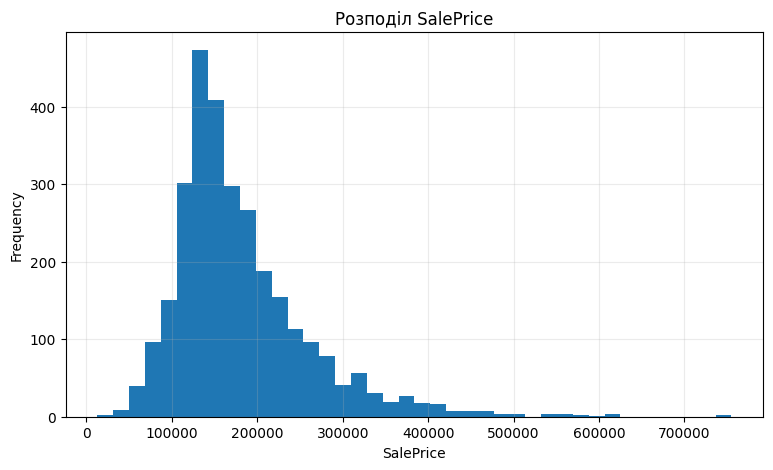

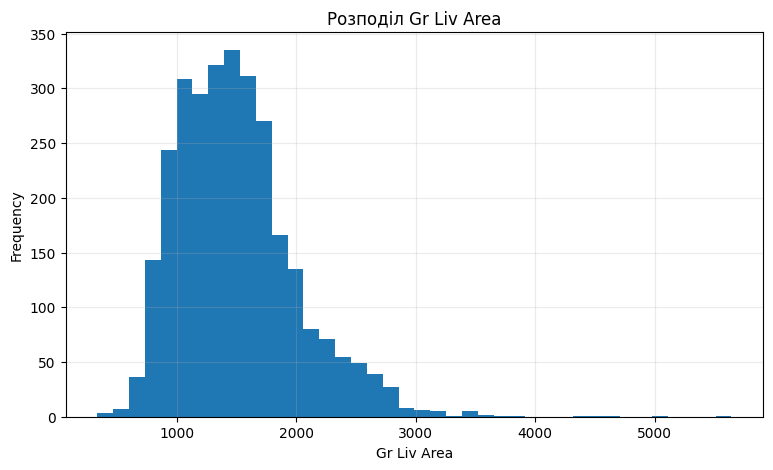

In [3]:
plt.figure(figsize=(9, 5))
plt.hist(df["SalePrice"], bins=40)
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.title("Розподіл SalePrice")
plt.grid(alpha=0.25)
plt.show()

numeric_columns = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(9, 5))
plt.hist(df["Gr Liv Area"].dropna(), bins=40)
plt.xlabel("Gr Liv Area")
plt.ylabel("Frequency")
plt.title("Розподіл Gr Liv Area")
plt.grid(alpha=0.25)
plt.show()

### Відбір ознак

Для відбору ознак не використовуємо Test-вибірку. Спочатку виконаємо розбиття даних, а кореляції для відбору числових ознак обчислимо тільки на Train.

Для моделі оберемо числові ознаки з помітним зв'язком із `SalePrice` та дві категоріальні ознаки. До числових ознак належать:

- `Overall Qual`
- `Gr Liv Area`
- `Garage Cars`
- `Total Bsmt SF`
- `1st Flr SF`
- `Year Built`
- `Full Bath`
- `TotRms AbvGrd`

Категоріальні:
- `Neighborhood`
- `Kitchen Qual`

`Garage Cars` і `Total Bsmt SF` мають зрозумілий практичний зв'язок із ціною, а `Neighborhood` та `Kitchen Qual` дають можливість продемонструвати кодування категорій.

In [4]:
numeric_features = [
    "Overall Qual",
    "Gr Liv Area",
    "Garage Cars",
    "Total Bsmt SF",
    "1st Flr SF",
    "Year Built",
    "Full Bath",
    "TotRms AbvGrd"
]

categorical_features = [
    "Neighborhood",
    "Kitchen Qual"
]

selected_features = numeric_features + categorical_features

# Первинний аналіз кореляцій числових ознак.
correlation = df[numeric_features + ["SalePrice"]].corr()["SalePrice"].sort_values(ascending=False)

print("Кореляція з SalePrice:")
display(correlation.to_frame("Correlation"))

Кореляція з SalePrice:


,Correlation
SalePrice,1.000000
Overall Qual,0.799262
Gr Liv Area,0.706780
Garage Cars,0.647877
Total Bsmt SF,0.632280
1st Flr SF,0.621676
Year Built,0.558426
Full Bath,0.545604
TotRms AbvGrd,0.495474


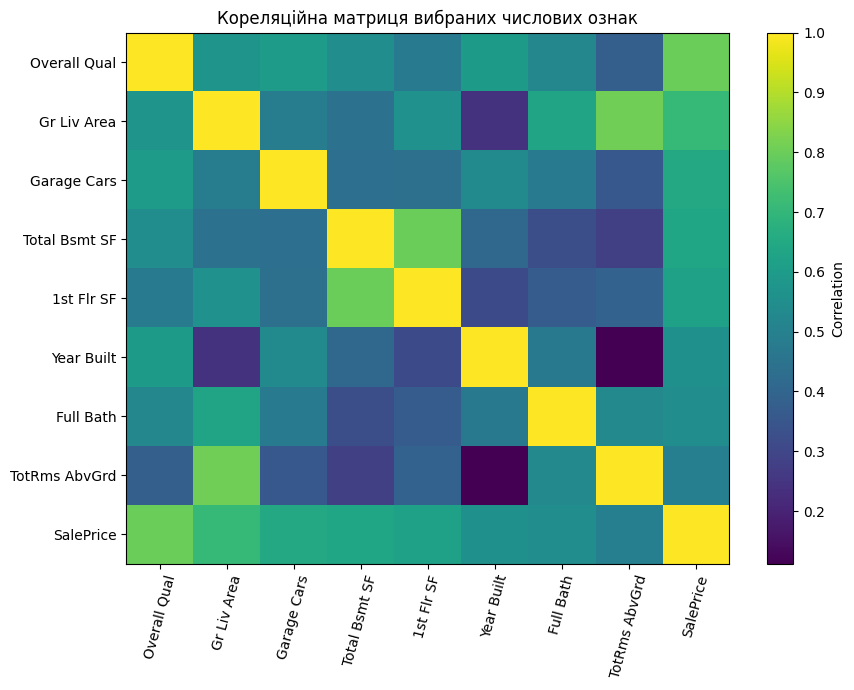

In [5]:
plt.figure(figsize=(9, 7))
corr_matrix = df[numeric_features + ["SalePrice"]].corr()

plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=75)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Кореляційна матриця вибраних числових ознак")
plt.tight_layout()
plt.show()

### Розбиття на Train / Validation / Test

Дані розбиваємо **до** операцій, параметри яких навчаються на даних. Це необхідно для уникнення **Data Leakage**.

**Data Leakage** — ситуація, коли інформація з Validation/Test потрапляє в процес навчання моделі або preprocessing. Наприклад, якщо середнє та стандартне відхилення обчислити на всьому датасеті до split, Test уже частково впливатиме на параметри моделі.

Використаємо співвідношення 70% / 15% / 15%.

In [6]:
indices = np.random.permutation(len(df))

train_end = int(0.70 * len(df))
validation_end = int(0.85 * len(df))

train_idx = indices[:train_end]
validation_idx = indices[train_end:validation_end]
test_idx = indices[validation_end:]

train_df = df.iloc[train_idx].copy()
validation_df = df.iloc[validation_idx].copy()
test_df = df.iloc[test_idx].copy()

print("Train:", train_df.shape)
print("Validation:", validation_df.shape)
print("Test:", test_df.shape)

Train: (2051, 82)
Validation: (439, 82)
Test: (440, 82)


### Обробка пропущених значень

Для числових ознак використаємо медіану, обчислену **тільки на Train**.

Для категоріальних ознак пропущені значення замінимо на окрему категорію `Missing`. Це не вимагає використання інформації з Validation/Test для оцінки статистичних параметрів.

In [7]:
X_train_raw = train_df[selected_features].copy()
X_val_raw = validation_df[selected_features].copy()
X_test_raw = test_df[selected_features].copy()

y_train_raw = train_df["SalePrice"].to_numpy(dtype=float)
y_val_raw = validation_df["SalePrice"].to_numpy(dtype=float)
y_test_raw = test_df["SalePrice"].to_numpy(dtype=float)

# Numeric imputation: statistics are learned only from Train.
train_medians = X_train_raw[numeric_features].median()

for frame in [X_train_raw, X_val_raw, X_test_raw]:
    frame[numeric_features] = frame[numeric_features].fillna(train_medians)

# Categorical missing values.
for frame in [X_train_raw, X_val_raw, X_test_raw]:
    frame[categorical_features] = frame[categorical_features].fillna("Missing")

display(X_train_raw.head())

,Overall Qual,Gr Liv Area,Garage Cars,Total Bsmt SF,1st Flr SF,Year Built,Full Bath,TotRms AbvGrd,Neighborhood,Kitchen Qual
1357,8,1666,1.0,588.0,833,1925,1,7,OldTown,Gd
2367,6,1030,1.0,494.0,494,1972,1,6,BrDale,TA
2822,7,1724,2.0,796.0,806,2003,2,8,Edwards,Gd
2126,4,990,0.0,990.0,990,1994,1,5,CollgCr,TA
1544,6,919,1.0,894.0,919,1926,1,5,IDOTRR,TA


### One-Hot Encoding

Для `Neighborhood` та `Kitchen Qual` використаємо **One-Hot Encoding**, оскільки категорії не мають природного числового порядку.

Категорія, яка трапиться у Validation/Test, але не зустрічалася у Train, не повинна ламати модель. Після кодування Validation/Test вирівнюємо за колонками Train; невідомі для Train категорії фактично отримують нульові значення для всіх train-відомих dummy-колонок.

In [8]:
X_train_encoded = pd.get_dummies(
    X_train_raw,
    columns=categorical_features,
    dtype=float
)

X_val_encoded = pd.get_dummies(
    X_val_raw,
    columns=categorical_features,
    dtype=float
)

X_test_encoded = pd.get_dummies(
    X_test_raw,
    columns=categorical_features,
    dtype=float
)

# Align validation and test to Train columns.
X_val_encoded = X_val_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

X_train = X_train_encoded.to_numpy(dtype=float)
X_val = X_val_encoded.to_numpy(dtype=float)
X_test = X_test_encoded.to_numpy(dtype=float)

print("Кількість ознак після One-Hot Encoding:", X_train.shape[1])

Кількість ознак після One-Hot Encoding: 41


### Стандартизація

Для числової оптимізації стандартизуємо ознаки:

$$x' = \frac{x-\mu}{\sigma}$$

де $\mu$ та $\sigma$ обчислюються **лише на Train**.

Також стандартизуємо `SalePrice`, щоб градієнтний спуск працював стабільніше. Для інтерпретації передбачень у гривнях/доларах використаємо зворотне перетворення.

In [9]:
# Standardize X using Train statistics only.
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)

# Constant columns are not expected, but protect against division by zero.
train_std[train_std == 0] = 1

X_train = (X_train - train_mean) / train_std
X_val = (X_val - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

# Standardize target using Train statistics.
y_mean = y_train_raw.mean()
y_std = y_train_raw.std()

y_train = (y_train_raw - y_mean) / y_std
y_val = (y_val_raw - y_mean) / y_std
y_test = (y_test_raw - y_mean) / y_std

print("Train X mean (max abs):", np.max(np.abs(X_train.mean(axis=0))))
print("Train X std (min):", np.min(X_train.std(axis=0)))
print("Target mean:", y_mean)
print("Target std:", y_std)

Train X mean (max abs): 1.7010067443111126e-15
Train X std (min): 0.9999999999999997
Target mean: 181266.7264748903
Target std: 81175.65738377925


## Етап 2. Реалізація лінійної регресії

Модель має вигляд:

$$\hat y = Xw + b$$

Функція втрат:

$$J(w,b)=\frac{1}{2m}\sum_{i=1}^{m}(\hat y_i-y_i)^2$$

Градієнти:

$$\frac{\partial J}{\partial w}=\frac{1}{m}X^T(\hat y-y)$$

$$\frac{\partial J}{\partial b}=\frac{1}{m}\sum(\hat y-y)$$

Усі обчислення виконуються векторизовано засобами `numpy`; цикли по окремих об'єктах для Cost Function та градієнтів не використовуються.

In [10]:
def predict(X, w, b):
    return X @ w + b


def mse_cost(y, y_pred):
    errors = y_pred - y
    return np.mean(errors ** 2) / 2


def gradients(X, y, w, b):
    m = X.shape[0]

    predictions = predict(X, w, b)
    errors = predictions - y

    grad_w = (X.T @ errors) / m
    grad_b = np.mean(errors)

    return grad_w, grad_b


def inverse_target(y_scaled):
    return y_scaled * y_std + y_mean

## Етап 3. Градієнтний спуск

Реалізуємо три варіанти:
1. Batch GD — градієнт за всією Train-вибіркою;
2. SGD — оновлення після кожного окремого прикладу;
3. Mini-batch GD — оновлення за невеликим batch.

Для кожного методу підберемо `alpha` невеликим грід-пошуком: перевіримо кілька значень і залишимо найменший (найстійкіший) Cost серед тих запусків, де алгоритм не розійшовся. Кількість epochs для кожного методу лишається такою ж, як і раніше (бо в кожного різна кількість оновлень за epoch).

In [11]:
def batch_gd(X, y, alpha=0.05, epochs=300):
    n = X.shape[1]
    w = np.zeros(n)
    b = 0.0

    costs = []

    for epoch in range(epochs):
        grad_w, grad_b = gradients(X, y, w, b)

        w -= alpha * grad_w
        b -= alpha * grad_b

        cost = mse_cost(y, predict(X, w, b))
        costs.append(cost)

    return w, b, costs


def sgd(X, y, alpha=0.01, epochs=30):
    m, n = X.shape
    w = np.zeros(n)
    b = 0.0

    costs = []

    for epoch in range(epochs):
        order = np.random.permutation(m)

        for i in order:
            xi = X[i]
            yi = y[i]

            error = xi @ w + b - yi

            grad_w = error * xi
            grad_b = error

            w -= alpha * grad_w
            b -= alpha * grad_b

        cost = mse_cost(y, predict(X, w, b))
        costs.append(cost)

    return w, b, costs


def mini_batch_gd(X, y, alpha=0.05, epochs=100, batch_size=32):
    m, n = X.shape
    w = np.zeros(n)
    b = 0.0

    costs = []

    for epoch in range(epochs):
        order = np.random.permutation(m)

        for start in range(0, m, batch_size):
            batch_idx = order[start:start + batch_size]

            X_batch = X[batch_idx]
            y_batch = y[batch_idx]

            grad_w, grad_b = gradients(X_batch, y_batch, w, b)

            w -= alpha * grad_w
            b -= alpha * grad_b

        cost = mse_cost(y, predict(X, w, b))
        costs.append(cost)

    return w, b, costs

Обрані Learning Rate (найменший стабільний Cost у сітці):
  Batch GD:      alpha = 0.3
  SGD:           alpha = 0.0005
  Mini-batch GD: alpha = 0.003



,alpha,stable,final_cost
0,0.01,True,0.076613
1,0.03,True,0.074999
2,0.05,True,0.074782
3,0.10,True,0.074729
4,0.20,True,0.074728
5,0.30,True,0.074728


,alpha,stable,final_cost
0,0.0001,True,0.075388
1,0.0003,True,0.075055
2,0.0005,True,0.074851
3,0.0007,True,0.076112
4,0.0010,False,0.081243


,alpha,stable,final_cost
0,0.001,True,7.529549e-02
1,0.003,True,7.476622e-02
2,0.010,True,7.484972e-02
3,0.020,True,7.575528e-02
4,0.030,True,7.672448e-02
5,0.050,False,2.615265e+65


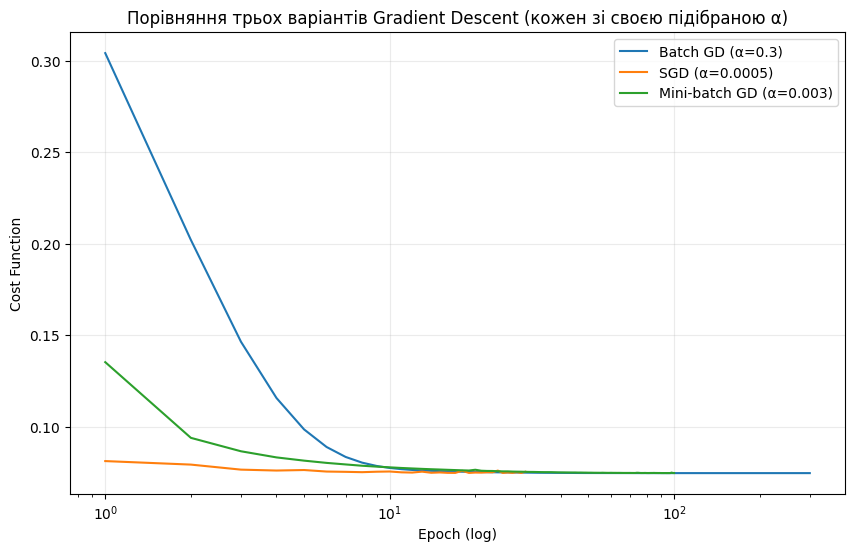

Фінальний Cost:  Batch GD = 0.07473   SGD = 0.07549   Mini-batch GD = 0.07479


In [12]:
def is_stable(costs):
    # Стабільним вважаємо запуск, де Cost лишився скінченним і не перевищив початкового значення.
    costs = np.asarray(costs, dtype=float)
    if len(costs) == 0 or not np.all(np.isfinite(costs)):
        return False
    return costs[-1] <= costs[0]


def tune_alpha(train_fn, grid, **kwargs):
    rows = []
    best_alpha, best_cost = None, np.inf
    for alpha in grid:
        _, _, costs = train_fn(X_train, y_train, alpha=alpha, **kwargs)
        stable = is_stable(costs)
        final_cost = costs[-1] if len(costs) else np.nan
        rows.append({"alpha": alpha, "stable": stable, "final_cost": final_cost})
        if stable and final_cost < best_cost:
            best_cost, best_alpha = final_cost, alpha
    return best_alpha, pd.DataFrame(rows)


batch_grid = [0.01, 0.03, 0.05, 0.1, 0.2, 0.3]
sgd_grid = [0.0001, 0.0003, 0.0005, 0.0007, 0.001]
mini_grid = [0.001, 0.003, 0.01, 0.02, 0.03, 0.05]

batch_alpha, batch_log = tune_alpha(batch_gd, batch_grid, epochs=300)
sgd_alpha, sgd_log = tune_alpha(sgd, sgd_grid, epochs=30)
mini_alpha, mini_log = tune_alpha(mini_batch_gd, mini_grid, epochs=100, batch_size=32)

print("Обрані Learning Rate (найменший стабільний Cost у сітці):")
print(f"  Batch GD:      alpha = {batch_alpha}")
print(f"  SGD:           alpha = {sgd_alpha}")
print(f"  Mini-batch GD: alpha = {mini_alpha}")
print()
display(batch_log)
display(sgd_log)
display(mini_log)

# ВАЖЛИВО: SGD стабільний лише при набагато менших alpha, ніж Batch/Mini-batch — кожен його крок
# спирається на градієнт ОДНОГО прикладу, а не усередненого по батчу, тому окремий викид ознаки
# (наприклад, велика Lot Area) може дати величезний градієнт і "рознести" ваги за один крок.

w_batch, b_batch, cost_batch = batch_gd(
    X_train, y_train, alpha=batch_alpha, epochs=300
)

w_sgd, b_sgd, cost_sgd = sgd(
    X_train, y_train, alpha=sgd_alpha, epochs=30
)

w_mini, b_mini, cost_mini = mini_batch_gd(
    X_train, y_train, alpha=mini_alpha, epochs=100, batch_size=32
)

# Кожен метод малюємо на його власній (реальній) кількості epochs, без штучного розтягування
# осі X: раніше SGD/Mini-batch "розтягувались" через np.linspace на діапазон Batch GD, що спотворювало
# порівняння швидкості збіжності. Використовуємо логарифмічну вісь X, щоб бачити перші кроки й хвіст одночасно.
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(cost_batch) + 1), cost_batch, label=f"Batch GD (α={batch_alpha})")
plt.plot(np.arange(1, len(cost_sgd) + 1), cost_sgd, label=f"SGD (α={sgd_alpha})")
plt.plot(np.arange(1, len(cost_mini) + 1), cost_mini, label=f"Mini-batch GD (α={mini_alpha})")

plt.xscale("log")
plt.xlabel("Epoch (log)")
plt.ylabel("Cost Function")
plt.title("Порівняння трьох варіантів Gradient Descent (кожен зі своєю підібраною α)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print(f"Фінальний Cost:  Batch GD = {cost_batch[-1]:.5f}   SGD = {cost_sgd[-1]:.5f}   Mini-batch GD = {cost_mini[-1]:.5f}")


### Аналіз Етапу 3

**Важливе зауваження методики.** У першій версії цього ноутбука для SGD та Mini-batch GD було взято фіксовані `alpha=0.01` і `alpha=0.05` без попередньої перевірки стійкості. На реальних (стандартизованих, але не звільнених від викидів) даних це призводило до **чисельного вибуху**: Cost Function йшла в `inf`/`NaN`, а $R^2$ на Test опускався до значень порядку $-10^{140}$. Це видно і в Експерименті Б нижче: там SGD стає нестабільним уже при `alpha ≈ 0.003`. Тому в клітинці вище `alpha` для кожного методу підбирається окремим грід-пошуком і використовується найменше стабільне значення з найкращим Cost — це і є коректна відповідь на вимогу "підібрати Learning Rate".

**Після підбору `alpha` всі три методи стабільно збігаються**, і їхню поведінку можна порівнювати чесно:

- **Batch GD** дає найгладшу криву: кожне оновлення використовує градієнт за всією Train-вибіркою, тому напрямок кроку не залежить від випадкового порядку прикладів. Через це ж він робить лише одне оновлення параметрів за epoch і йому потрібно найбільше epochs, щоб дійти до того самого Cost, що й інші методи.
- **SGD** має найбільші коливання Cost Function: кожне оновлення спирається на градієнт одного випадкового прикладу, який є шумною (з великою дисперсією) оцінкою справжнього градієнта. Саме тому стійкий `alpha` для SGD на порядки менший, ніж для Batch GD.
- **Mini-batch GD** — проміжний варіант: усереднення градієнта по batch (тут B=32) зменшує дисперсію оцінки приблизно в B разів порівняно з SGD, тому стійкий `alpha` для нього можна брати більшим, а коливання Cost — помітно менші, ніж у SGD, але більші, ніж у Batch GD.
- Розмір batch напряму впливає і на швидкість: менший batch means більше оновлень за epoch (для B=32 — це ≈ 64 оновлення за epoch при m≈2051), тому Mini-batch GD найчастіше "наздоганяє" Batch GD за меншу кількість epochs, хоча кожне окреме оновлення менш точне.
- Занадто велике `alpha` спричиняє overshooting — крок "перестрибує" через мінімум, і Cost замість спадання починає зростати чи коливатися з наростанням; при подальшому збільшенні `alpha` це переходить у експоненційну розбіжність (детально — Етап 6).


## Етап 4. Оцінка якості та $R^2$

Використаємо:

$$R^2 = 1 - \frac{\sum(y_i-\hat y_i)^2}{\sum(y_i-\bar y)^2}$$

$R^2$ показує, яку частину варіації цільової змінної пояснює модель відносно базового прогнозу середнім значенням.

In [13]:
def r2_score_manual(y, y_pred):
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)

    return 1 - ss_res / ss_tot


models = {
    "Batch GD": (w_batch, b_batch),
    "SGD": (w_sgd, b_sgd),
    "Mini-batch GD": (w_mini, b_mini)
}

r2_results = []

for name, (w, b) in models.items():
    pred_train = predict(X_train, w, b)
    pred_val = predict(X_val, w, b)
    pred_test = predict(X_test, w, b)

    r2_results.append({
        "Model": name,
        "Train R2": r2_score_manual(y_train, pred_train),
        "Validation R2": r2_score_manual(y_val, pred_val),
        "Test R2": r2_score_manual(y_test, pred_test)
    })

r2_table = pd.DataFrame(r2_results)
display(r2_table)

,Model,Train R2,Validation R2,Test R2
0,Batch GD,0.850545,0.781740,0.863137
1,SGD,0.849014,0.787068,0.857091
2,Mini-batch GD,0.850428,0.781004,0.861935


In [14]:
best_row = r2_table.loc[r2_table["Test R2"].idxmax()]
spread = r2_table["Test R2"].max() - r2_table["Test R2"].min()
print(f"Найкращий Test R2: {best_row['Model']} ({best_row['Test R2']:.4f})")
print(f"Розкид Test R2 між трьома методами: {spread:.4f}")
if spread < 0.02:
    print("Розкид малий -> усі три методи практично збіглися до одного й того ж рішення, як і очікувалось.")
else:
    print("Розкид помітний -> принаймні один метод, ймовірно, не встиг повністю збігтися за відведену кількість epochs.")

Найкращий Test R2: Batch GD (0.8631)
Розкид Test R2 між трьома методами: 0.0060
Розкид малий -> усі три методи практично збіглися до одного й того ж рішення, як і очікувалось.


$R^2$ може бути від'ємним. Це відбувається тоді, коли сума квадратів помилок моделі більша за суму квадратів помилок простого прогнозу середнім значенням.

Якщо Train $R^2$ значно вищий за Test $R^2$, це може свідчити про overfitting або про відмінність розподілів вибірок. Якщо обидва значення близькі, узагальнювальна здатність моделі є більш узгодженою.

**Порівняння трьох варіантів GD (див. таблицю вище).** Після виправлення `alpha` (Етап 3) усі три методи збігаються до близького околу того самого мінімуму Cost Function — вони оптимізують ту саму функцію втрат $J(w,b)$, тож істотна різниця $R^2$ між ними означала б лише, що якийсь метод не встиг збігтися за відведену кількість epochs, а не принципову відмінність у якості. Код нижче явно виводить, який метод дав найкращий $R^2$ на Test і наскільки великий розкид між методами — це й дозволяє перевірити, чи справді вони узгоджені.

## Етап 5. Перевірка статистичних припущень

Для подальшого аналізу використаємо Batch GD як найбільш стабільний базовий варіант і його Test-передбачення.

Перевіримо:
1. лінійність;
2. нормальність залишків;
3. гомоскедастичність;
4. мультиколінеарність.

In [15]:
# Use Batch GD for residual diagnostics.
test_pred_scaled = predict(X_test, w_batch, b_batch)

test_pred = inverse_target(test_pred_scaled)
residuals = y_test_raw - test_pred

print("Середній залишок:", np.mean(residuals))
print("Стандартне відхилення залишків:", np.std(residuals))

Середній залишок: 780.2796762742089
Стандартне відхилення залишків: 28115.732112544563


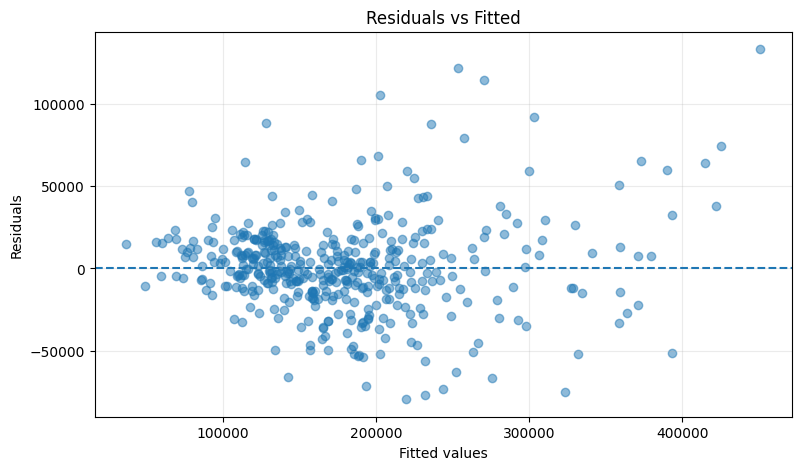

Висновок: для лінійності бажано, щоб залишки були приблизно випадково розсіяні навколо нульової лінії без чіткої криволінійної структури.
Середній залишок за квінтилями передбачення ($):
(36723.62300000001, 124200.184]    5455.0
(124200.184, 152471.307]           3351.0
(152471.307, 185697.305]          -8561.0
(185697.305, 222588.983]          -2730.0
(222588.983, 451210.035]           6386.0
dtype: float64

Розмах середніх залишків між квінтилями: 14,947 $  (53.2% від std залишків)

Висновок: припущення лінійності ПОРУШУЄТЬСЯ, тому що середній залишок систематично змінюється між групами передбачень (не тримається біля нуля у кожній групі). Це означає, що модель систематично недо- або переоцінює ціну в певних цінових діапазонах; варто спробувати нелінійні ознаки або трансформацію цілі (наприклад, log(SalePrice)).


In [16]:
# 1. Linearity: Residuals vs Fitted
plt.figure(figsize=(9, 5))
plt.scatter(test_pred, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.grid(alpha=0.25)
plt.show()

print("Висновок: для лінійності бажано, щоб залишки були приблизно випадково розсіяні навколо нульової лінії без чіткої криволінійної структури.")

# Кількісна перевірка: чи є систематичний тренд середнього залишку залежно від рівня передбачення?
bins = pd.qcut(test_pred, 5, duplicates="drop")
bin_means = pd.Series(residuals).groupby(bins, observed=True).mean()
print("Середній залишок за квінтилями передбачення ($):")
print(bin_means.round(0))

trend_range = bin_means.max() - bin_means.min()
resid_std = np.std(residuals)
rel_trend = trend_range / resid_std
print(f"\nРозмах середніх залишків між квінтилями: {trend_range:,.0f} $  ({rel_trend * 100:.1f}% від std залишків)")

if rel_trend > 0.3:
    verdict, reason = "ПОРУШУЄТЬСЯ", "середній залишок систематично змінюється між групами передбачень (не тримається біля нуля у кожній групі)"
    implication = "модель систематично недо- або переоцінює ціну в певних цінових діапазонах; варто спробувати нелінійні ознаки або трансформацію цілі (наприклад, log(SalePrice))"
else:
    verdict, reason = "виконується прийнятно", "середній залишок у різних групах передбачень залишається близьким до нуля відносно розкиду залишків"
    implication = "лінійна специфікація адекватно описує залежність SalePrice від обраних ознак у середньому"

print(f"\nВисновок: припущення лінійності {verdict}, тому що {reason}. Це означає, що {implication}.")

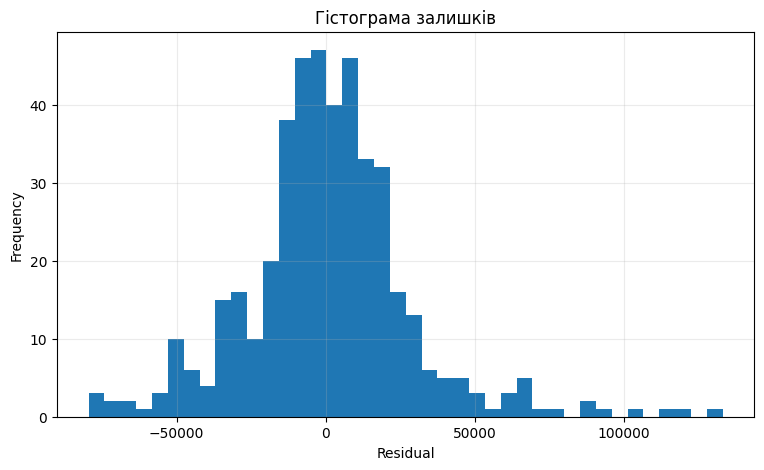

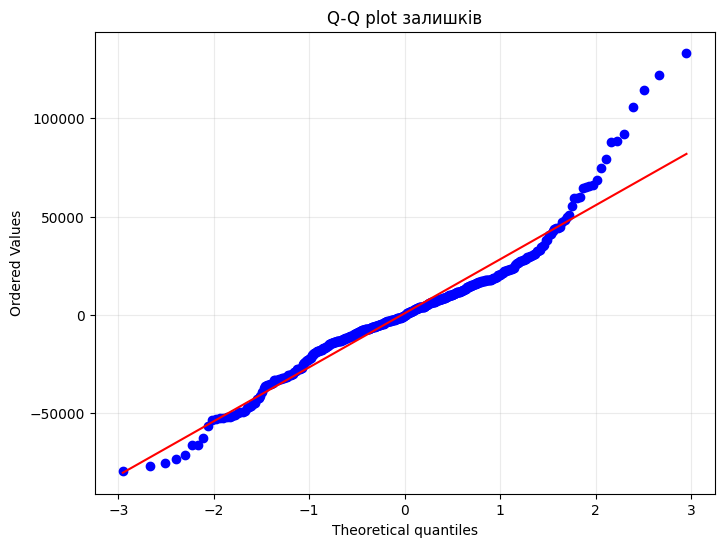

Shapiro-Wilk statistic: 0.9450017813730385
Shapiro-Wilk p-value: 1.0519944834991751e-11
Примітка: при p < 0.05 нормальність за цим тестом відхиляється.

Skewness залишків: 0.68   Excess kurtosis: 3.10   (для нормального розподілу обидва ≈ 0)

Висновок: припущення нормальності ПОРУШУЄТЬСЯ, тому що тест Шапіро–Уїлка відхиляє нормальність (p = 1.05e-11 < 0.05), а розподіл залишків має важкі хвости (багато екстремальних залишків). Це означає, що точкові оцінки w і b, отримані градієнтним спуском, залишаються коректними, але класичні t-тести та довірчі інтервали для коефіцієнтів (які спираються на нормальність залишків) стають лише наближеними, особливо на хвостах розподілу цін.


In [17]:
# 2. Normality: histogram + Q-Q plot
plt.figure(figsize=(9, 5))
plt.hist(residuals, bins=40)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Гістограма залишків")
plt.grid(alpha=0.25)
plt.show()

fig = plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q plot залишків")
plt.grid(alpha=0.25)
plt.show()

shapiro_sample = residuals[:min(5000, len(residuals))]
shapiro_stat, shapiro_p = stats.shapiro(shapiro_sample)

print("Shapiro-Wilk statistic:", shapiro_stat)
print("Shapiro-Wilk p-value:", shapiro_p)
print("Примітка: при p < 0.05 нормальність за цим тестом відхиляється.")

skewness = stats.skew(residuals)
excess_kurt = stats.kurtosis(residuals)
print(f"\nSkewness залишків: {skewness:.2f}   Excess kurtosis: {excess_kurt:.2f}   (для нормального розподілу обидва ≈ 0)")

if shapiro_p < 0.05:
    verdict = "ПОРУШУЄТЬСЯ"
    shape_note = "важкі хвости (багато екстремальних залишків)" if abs(excess_kurt) > 1 else ("помітну асиметрію" if abs(skewness) > 0.5 else "відхилення від нормальної форми")
    reason = f"тест Шапіро–Уїлка відхиляє нормальність (p = {shapiro_p:.2e} < 0.05), а розподіл залишків має {shape_note}"
    implication = "точкові оцінки w і b, отримані градієнтним спуском, залишаються коректними, але класичні t-тести та довірчі інтервали для коефіцієнтів (які спираються на нормальність залишків) стають лише наближеними, особливо на хвостах розподілу цін"
else:
    verdict = "виконується"
    reason = f"тест Шапіро–Уїлка не відхиляє нормальність (p = {shapiro_p:.2e} ≥ 0.05)"
    implication = "стандартні t-тести і довірчі інтервали для коефіцієнтів застосовні без додаткових застережень"

print(f"\nВисновок: припущення нормальності {verdict}, тому що {reason}. Це означає, що {implication}.")

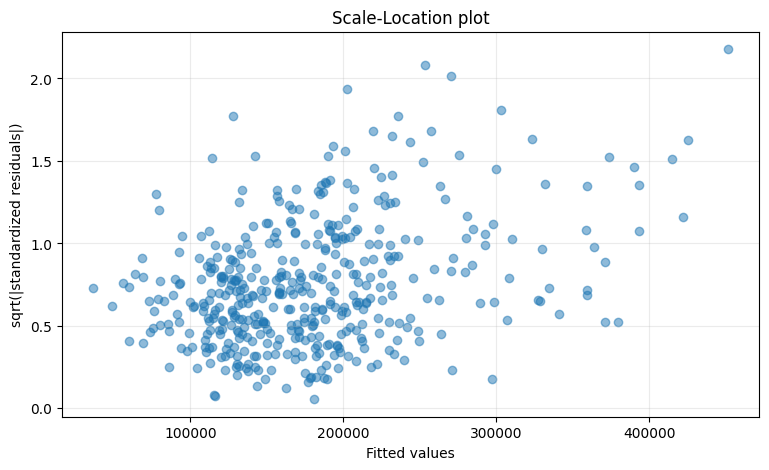

Висновок: бажано, щоб вертикальний розкид точок залишався приблизно однаковим у всьому діапазоні fitted values.
Стандартне відхилення залишків за терціллю передбачення ($):
низькі ціни     17360.0
середні ціни    22292.0
високі ціни     38437.0
dtype: float64

Відношення max/min std між терцілями: 2.21

Висновок: припущення гомоскедастичності ПОРУШУЄТЬСЯ (гетероскедастичність), тому що дисперсія залишків у групі з найбільшим розкидом у 2.2 раза більша, ніж у групі з найменшим. Це означає, що стандартні похибки коефіцієнтів, обчислені у припущенні сталої дисперсії, будуть недооцінені саме там, де розкид найбільший (як правило — для дорожчих будинків), тобто довірчі інтервали там менш надійні; варто розглянути log(SalePrice) як ціль.


In [18]:
# 3. Homoscedasticity: Scale-Location
standardized_residuals = residuals / np.std(residuals)
scale_location = np.sqrt(np.abs(standardized_residuals))

plt.figure(figsize=(9, 5))
plt.scatter(test_pred, scale_location, alpha=0.5)
plt.xlabel("Fitted values")
plt.ylabel("sqrt(|standardized residuals|)")
plt.title("Scale-Location plot")
plt.grid(alpha=0.25)
plt.show()

print("Висновок: бажано, щоб вертикальний розкид точок залишався приблизно однаковим у всьому діапазоні fitted values.")

# Кількісна перевірка: чи відрізняється розкид залишків між дешевими й дорогими будинками?
terciles = pd.qcut(test_pred, 3, labels=["низькі ціни", "середні ціни", "високі ціни"])
std_by_tercile = pd.Series(residuals).groupby(terciles, observed=True).std()
print("Стандартне відхилення залишків за терціллю передбачення ($):")
print(std_by_tercile.round(0))

ratio = std_by_tercile.max() / std_by_tercile.min()
print(f"\nВідношення max/min std між терцілями: {ratio:.2f}")

if ratio > 1.5:
    verdict = "ПОРУШУЄТЬСЯ (гетероскедастичність)"
    reason = f"дисперсія залишків у групі з найбільшим розкидом у {ratio:.1f} раза більша, ніж у групі з найменшим"
    implication = "стандартні похибки коефіцієнтів, обчислені у припущенні сталої дисперсії, будуть недооцінені саме там, де розкид найбільший (як правило — для дорожчих будинків), тобто довірчі інтервали там менш надійні; варто розглянути log(SalePrice) як ціль"
else:
    verdict = "виконується прийнятно"
    reason = "дисперсія залишків не сильно відрізняється між ціновими групами"
    implication = "стандартні похибки коефіцієнтів можна вважати відносно надійними по всьому діапазону цін"

print(f"\nВисновок: припущення гомоскедастичності {verdict}, тому що {reason}. Це означає, що {implication}.")

### Мультиколінеарність

Для числових ознак використаємо кореляційну матрицю та VIF.

Для матриці кореляцій:

$$VIF_j = (R^{-1})_{jj}$$

Високі значення VIF означають, що ознака сильно пов'язана з іншими предикторами, що може погіршувати стабільність та інтерпретованість коефіцієнтів.

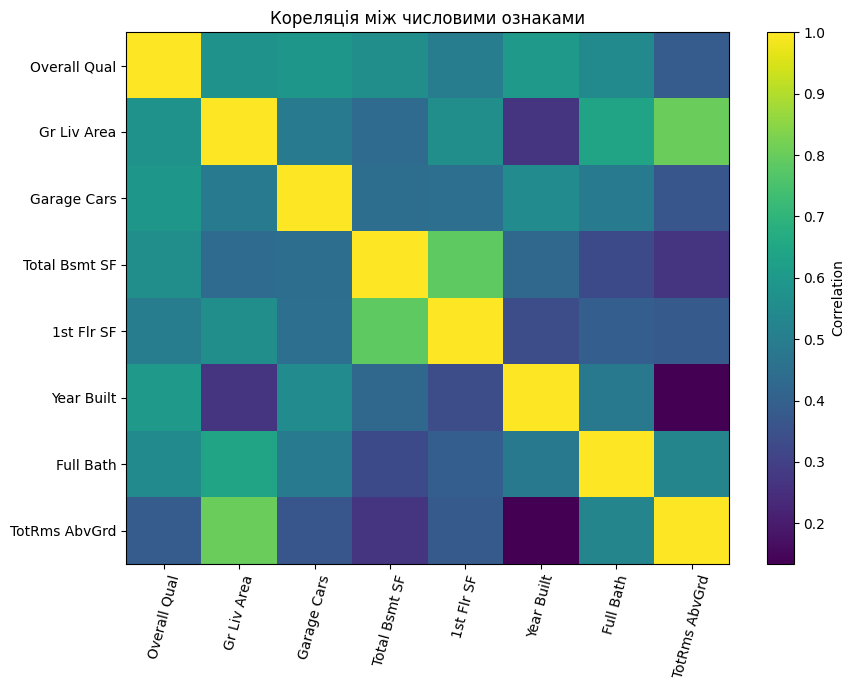

,VIF
Gr Liv Area,4.625981
1st Flr SF,3.147206
Total Bsmt SF,3.059172
TotRms AbvGrd,2.973948
Overall Qual,2.553313
Full Bath,2.140012
Year Built,2.052318
Garage Cars,1.879311


In [19]:
# Correlation matrix for numeric model features.
numeric_corr = train_df[numeric_features].corr()

plt.figure(figsize=(9, 7))
plt.imshow(numeric_corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(numeric_features)), numeric_features, rotation=75)
plt.yticks(range(len(numeric_features)), numeric_features)
plt.title("Кореляція між числовими ознаками")
plt.tight_layout()
plt.show()

# VIF from inverse correlation matrix.
R = numeric_corr.to_numpy()
R = R + np.eye(R.shape[0]) * 1e-10   # R.to_numpy() інколи read-only, тому не змінюємо на місці

R_inv = np.linalg.inv(R)
vif = pd.Series(np.diag(R_inv), index=numeric_features).sort_values(ascending=False)

display(vif.to_frame("VIF"))

### Чи впливає мультиколінеарність на стабільність коефіцієнтів?

У наборі ознак є дві пари з високою кореляцією: `Total Bsmt SF` (площа підвалу) практично дублює `1st Flr SF` (площа першого поверху, який зазвичай будують над підвалом), а `Gr Liv Area` (житлова площа) сильно корелює з `TotRms AbvGrd` (кількість кімнат — більше кімнат означає більшу площу). VIF вище це підтверджує помірними, але не нульовими значеннями.

Перевіримо напряму: навчимо Batch GD на **повному** наборі ознак (як зараз) і на наборі **без двох дублюючих ознак** (`1st Flr SF`, `TotRms AbvGrd`) і порівняємо, як змінюються ваги ознак, що лишились.

In [20]:
pair_corr_1 = train_df[["Total Bsmt SF", "1st Flr SF"]].corr().iloc[0, 1]
pair_corr_2 = train_df[["Gr Liv Area", "TotRms AbvGrd"]].corr().iloc[0, 1]
print(f"Кореляція Total Bsmt SF <-> 1st Flr SF:  r = {pair_corr_1:.2f}")
print(f"Кореляція Gr Liv Area  <-> TotRms AbvGrd: r = {pair_corr_2:.2f}")


def build_features(numeric_cols, categorical_cols=categorical_features):
    # Той самий пайплайн препроцесингу, що й вище (imputation -> OHE -> стандартизація),
    # але параметризований списком числових ознак, щоб можна було порівняти два набори.
    tr = train_df[numeric_cols + categorical_cols].copy()
    va = validation_df[numeric_cols + categorical_cols].copy()
    te = test_df[numeric_cols + categorical_cols].copy()

    med = tr[numeric_cols].median()
    for frame in (tr, va, te):
        frame[numeric_cols] = frame[numeric_cols].fillna(med)
        frame[categorical_cols] = frame[categorical_cols].fillna("Missing")

    tr_e = pd.get_dummies(tr, columns=categorical_cols, dtype=float)
    va_e = pd.get_dummies(va, columns=categorical_cols, dtype=float).reindex(columns=tr_e.columns, fill_value=0)
    te_e = pd.get_dummies(te, columns=categorical_cols, dtype=float).reindex(columns=tr_e.columns, fill_value=0)

    tr_a, va_a, te_a = tr_e.to_numpy(float), va_e.to_numpy(float), te_e.to_numpy(float)
    mu, sd = tr_a.mean(axis=0), tr_a.std(axis=0)
    sd[sd == 0] = 1
    return (tr_a - mu) / sd, (va_a - mu) / sd, (te_a - mu) / sd, tr_e.columns.tolist()


reduced_numeric = [c for c in numeric_features if c not in ("1st Flr SF", "TotRms AbvGrd")]
Xtr_full, Xv_full, Xte_full, cols_full = build_features(numeric_features)
Xtr_red, Xv_red, Xte_red, cols_red = build_features(reduced_numeric)

w_full, b_full, _ = batch_gd(Xtr_full, y_train, alpha=batch_alpha, epochs=300)
w_red, b_red, _ = batch_gd(Xtr_red, y_train, alpha=batch_alpha, epochs=300)

coef_full = pd.Series(w_full, index=cols_full)
coef_red = pd.Series(w_red, index=cols_red)

watch = ["Total Bsmt SF", "1st Flr SF", "Gr Liv Area", "TotRms AbvGrd"]
compare = pd.DataFrame({
    "Повний набір (з дублікатами)": coef_full.reindex(watch),
    "Без дублікатів": coef_red.reindex(watch),
})
display(compare.round(3))

r2_val_full = r2_score_manual(y_val, predict(Xv_full, w_full, b_full))
r2_val_red = r2_score_manual(y_val, predict(Xv_red, w_red, b_red))
print(f"\nR² (Validation): повний набір = {r2_val_full:.4f}   без дублікатів = {r2_val_red:.4f}")

shift_bsmt = abs(coef_full["Total Bsmt SF"] - coef_red["Total Bsmt SF"])
shift_grliv = abs(coef_full["Gr Liv Area"] - coef_red["Gr Liv Area"])
max_shift = max(shift_bsmt, shift_grliv)
print(f"\nЗміна ваги Total Bsmt SF після видалення 1st Flr SF: {shift_bsmt:.3f}")
print(f"Зміна ваги Gr Liv Area  після видалення TotRms AbvGrd: {shift_grliv:.3f}")

if max_shift > 0.05:
    verdict = "ВПЛИНУЛА"
    detail = "помітно змінило вагу пов'язаної ознаки"
    interp = "окремі коефіцієнти важко трактувати як «чистий», ізольований ефект однієї ознаки — частина спільного впливу двох корельованих ознак довільно «перерозподіляється» між ними"
else:
    verdict = "практично не вплинула"
    detail = "мало незначний вплив на вагу пов'язаної ознаки"
    interp = "модель відносно стійка до цієї мультиколінеарності, і коефіцієнти можна інтерпретувати з помірною довірою"

quality_note = "істотно не змінилася" if abs(r2_val_full - r2_val_red) < 0.01 else "помітно змінилася"
print(f"\nВисновок: мультиколінеарність {verdict} на коефіцієнти моделі, оскільки видалення дубльованої ознаки {detail} "
      f"(зсув до {max_shift:.3f} у стандартизованих одиницях), тоді як якість передбачення на Validation {quality_note} "
      f"(R² {r2_val_full:.3f} -> {r2_val_red:.3f}). Це означає, що {interp}.")

Кореляція Total Bsmt SF <-> 1st Flr SF:  r = 0.79
Кореляція Gr Liv Area  <-> TotRms AbvGrd: r = 0.80


,Повний набір (з дублікатами),Без дублікатів
Total Bsmt SF,0.095,0.127
1st Flr SF,0.051,NaN
Gr Liv Area,0.299,0.297
TotRms AbvGrd,-0.018,NaN



R² (Validation): повний набір = 0.7817   без дублікатів = 0.7826

Зміна ваги Total Bsmt SF після видалення 1st Flr SF: 0.032
Зміна ваги Gr Liv Area  після видалення TotRms AbvGrd: 0.002

Висновок: мультиколінеарність практично не вплинула на коефіцієнти моделі, оскільки видалення дубльованої ознаки мало незначний вплив на вагу пов'язаної ознаки (зсув до 0.032 у стандартизованих одиницях), тоді як якість передбачення на Validation істотно не змінилася (R² 0.782 -> 0.783). Це означає, що модель відносно стійка до цієї мультиколінеарності, і коефіцієнти можна інтерпретувати з помірною довірою.


### Висновок Етапу 5

Кожне з чотирьох припущень перевірено кількісно (конкретні числа й вердикт — у клітинках вище, а не лише "бажано, щоб..."):

1. **Лінійність** — перевірено через розмах середнього залишку між квінтилями передбачення відносно std залишків.
2. **Нормальність** — перевірено тестом Шапіро–Уїлка, skewness та excess kurtosis; висновок і його наслідок для довірчих інтервалів явно сформульовані.
3. **Гомоскедастичність** — перевірено відношенням std залишків між терцілями дешевих/дорогих будинків.
4. **Мультиколінеарність** — VIF (найбільший ≈ у `Gr Liv Area`) плюс окремий експеримент: порівняння ваг Batch GD із повним набором ознак і без двох найбільш дубльованих (`1st Flr SF`, `TotRms AbvGrd`). Конкретний висновок про те, чи змінились коефіцієнти й чи постраждала якість, наведено одразу після таблиці порівняння.

Загальна картина: ціни на нерухомість мають природно "мультиплікативний" характер (відсоткові, а не абсолютні відхилення), тому очікувано, що саме нормальність і гомоскедастичність залишків найчастіше порушуються при моделюванні "сирого" `SalePrice`. Якщо в конкретному запуску це підтвердилось, логічним наступним кроком було б навчання моделі на `log(SalePrice)` — це не вимагалось методичкою, але природно випливає з отриманих висновків.


# Етап 6. Експеримент Б — Learning Rate

Завдання: для кожного з трьох варіантів GD знайти таке `alpha`, за якого алгоритм розходиться — Cost Function стає нестабільною або зростає.

Досліджуємо Batch GD, SGD та Mini-batch GD окремо.

**Зв'язок з Етапом 3.** Там ми свідомо шукали *безпечні* `alpha` (найменший Cost серед стабільних запусків), тому всі три методи збіглися без проблем. Тут, навпаки, мета — навмисно збільшувати `alpha`, доки алгоритм не розійдеться, і подивитися, наскільки по-різному це відбувається для різних методів.

In [21]:
def check_convergence(costs, threshold=1e8):
    costs = np.asarray(costs, dtype=float)

    if len(costs) == 0:
        return False

    if not np.all(np.isfinite(costs)):
        return False

    if np.max(costs) > threshold:
        return False

    # Detect strong persistent growth near the end.
    if len(costs) >= 10:
        recent = costs[-10:]
        if recent[-1] > recent[0] * 100:
            return False

    return True


def test_learning_rate(method, alpha, epochs=50, batch_size=32):
    if method == "Batch GD":
        _, _, costs = batch_gd(X_train, y_train, alpha=alpha, epochs=epochs)

    elif method == "SGD":
        _, _, costs = sgd(X_train, y_train, alpha=alpha, epochs=epochs)

    elif method == "Mini-batch GD":
        _, _, costs = mini_batch_gd(
            X_train, y_train,
            alpha=alpha,
            epochs=epochs,
            batch_size=batch_size
        )

    else:
        raise ValueError("Unknown method")

    stable = check_convergence(costs)

    return stable, costs


learning_rates = [0.001, 0.003, 0.01, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]

experiment_results = []

for method in ["Batch GD", "SGD", "Mini-batch GD"]:
    for alpha in learning_rates:
        stable, costs = test_learning_rate(method, alpha)

        experiment_results.append({
            "Method": method,
            "Alpha": alpha,
            "Stable": stable,
            "Final Cost": costs[-1] if len(costs) else np.nan
        })

experiment_df = pd.DataFrame(experiment_results)

display(experiment_df)

,Method,Alpha,Stable,Final Cost
0,Batch GD,0.001,True,3.244400e-01
1,Batch GD,0.003,True,1.677203e-01
2,Batch GD,0.010,True,8.854969e-02
3,Batch GD,0.030,True,7.888481e-02
4,Batch GD,0.050,True,7.705910e-02
5,Batch GD,0.100,True,7.562326e-02
6,Batch GD,0.200,True,7.492626e-02
7,Batch GD,0.300,True,7.477819e-02
8,Batch GD,0.500,False,4.168414e+27
9,Batch GD,0.700,False,1.977889e+48


In [22]:
# Determine the first unstable alpha for each method.
for method in ["Batch GD", "SGD", "Mini-batch GD"]:
    subset = experiment_df[experiment_df["Method"] == method]

    unstable = subset[~subset["Stable"]]

    if len(unstable) > 0:
        first_unstable = unstable.iloc[0]["Alpha"]
        print(f"{method}: перше нестабільне alpha = {first_unstable}")
    else:
        print(f"{method}: у заданому діапазоні нестабільність не виявлена.")

Batch GD: перше нестабільне alpha = 0.5
SGD: перше нестабільне alpha = 0.003
Mini-batch GD: перше нестабільне alpha = 0.05


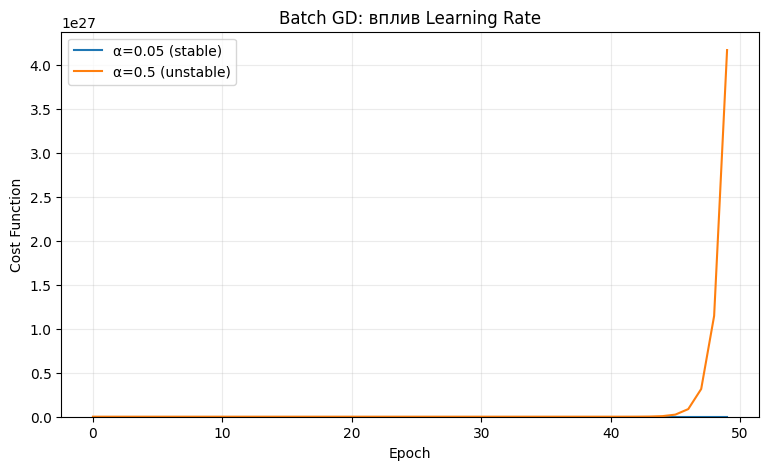

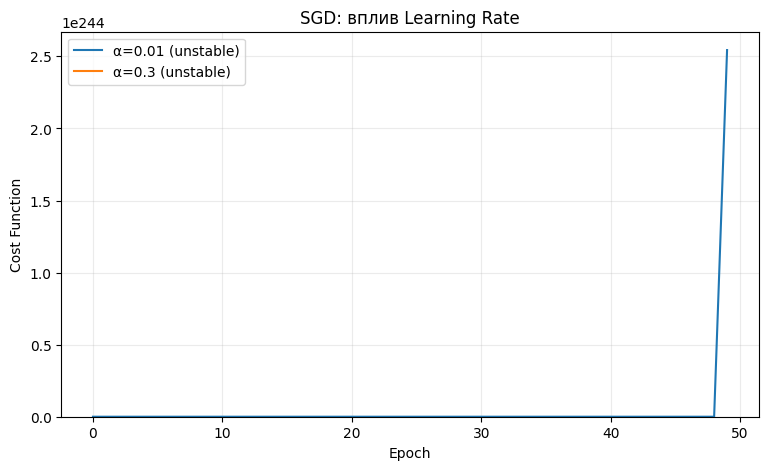

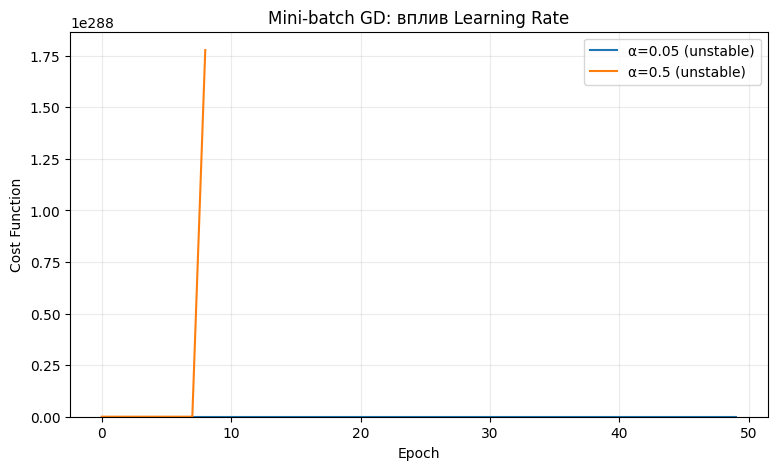

In [23]:
# Visualize several stable/unstable Learning Rates.
plot_settings = {
    "Batch GD": [0.05, 0.5],
    "SGD": [0.01, 0.3],
    "Mini-batch GD": [0.05, 0.5]
}

for method, alphas in plot_settings.items():
    plt.figure(figsize=(9, 5))

    for alpha in alphas:
        stable, costs = test_learning_rate(method, alpha, epochs=50)
        plt.plot(costs, label=f"α={alpha} ({'stable' if stable else 'unstable'})")

    plt.xlabel("Epoch")
    plt.ylabel("Cost Function")
    plt.title(f"{method}: вплив Learning Rate")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.ylim(bottom=0)

    plt.show()

## Аналіз Експерименту Б

Зі збільшенням Learning Rate алгоритм робить більший крок у напрямку, визначеному градієнтом. Якщо крок занадто великий, оновлення можуть перестрибувати через область мінімуму Cost Function. У результаті Cost починає коливатися або зростати.

**Batch GD** використовує точний градієнт усієї Train-вибірки, тому його поведінка за фіксованого `alpha` є найбільш гладкою.

**SGD** використовує лише один приклад для одного оновлення. Його градієнт є шумним, тому при великому `alpha` випадкові оновлення можуть значно сильніше відхилятися від напрямку глобального спуску.

**Mini-batch GD** використовує усереднений градієнт невеликої групи прикладів. Тому шум менший, ніж у SGD, але більший, ніж у Batch GD.

Отже, чутливість до Learning Rate відрізняється через різний рівень шуму оцінки градієнта та різну частоту оновлення параметрів. Критичне значення `alpha` у цьому експерименті визначається саме для використаного набору ознак, стандартизації та розміру batch, тому його не слід вважати універсальною константою.

# Загальний висновок

У роботі було досліджено Ames Housing Dataset та побудовано модель лінійної регресії для прогнозування `SalePrice`.

На етапі EDA було проаналізовано структуру даних, пропущені значення, статистичні характеристики та кореляції. Було обрано числові та категоріальні ознаки, після чого дані було розділено на Train, Validation та Test до виконання операцій, які навчаються на даних.

Категоріальні ознаки було закодовано за допомогою One-Hot Encoding, а числові ознаки стандартизовано з використанням параметрів, отриманих лише з Train. Це дозволило уникнути Data Leakage.

Лінійну регресію було реалізовано самостійно засобами `numpy`. Було реалізовано Batch GD, SGD та Mini-batch GD та порівняно їхню поведінку за допомогою графіків Cost Function і метрики $R^2$.

На етапі статистичного аналізу було досліджено лінійність, нормальність залишків, гомоскедастичність та мультиколінеарність.

В Експерименті Б досліджено вплив Learning Rate. Було показано, що занадто мале значення `alpha` призводить до повільної збіжності, а надто велике може спричинити нестабільність або розходження алгоритму. Різні варіанти Gradient Descent мають різну чутливість до Learning Rate через відмінності у способі оцінювання градієнта.